In [1]:
import pandas as pd

In [2]:
import numpy as np

In [4]:
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("../dataset/water_demand.csv")

df["Date"] = pd.to_datetime(df["Date"])

print("Dataset Shape:", df.shape)

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../dataset/water_demand.csv'

In [6]:
print("Columns:")
print(df.columns)

print("\nDataset Information:")
df.info()

Columns:


NameError: name 'df' is not defined

In [7]:
import os

print(os.getcwd())

C:\Users\HP\Water-Demand-Forecasting


In [8]:
import pandas as pd

df = pd.read_csv("dataset/water_demand.csv")

df["Date"] = pd.to_datetime(df["Date"])

print("Dataset Shape:", df.shape)

df.head()



NameError: name 'v' is not defined

In [9]:
import pandas as pd

df = pd.read_csv("dataset/water_demand.csv")

df["Date"] = pd.to_datetime(df["Date"])

print("Dataset Shape:", df.shape)

df.head()


Dataset Shape: (181, 11)


,Date,Group,Households_Supplied,Water_Per_Household_L,Total_Water_Supplied_L,Day,Month,Day_of_Week,Temperature,Rainfall,Humidity
0,2026-01-01,A,63,400,25200,1,1,3,20.8,0.0,52
1,2026-01-02,B,62,400,24800,2,1,4,21.3,0.1,55
2,2026-01-03,A,63,400,25200,3,1,5,22.6,0.0,53
3,2026-01-04,B,62,400,24800,4,1,6,22.3,0.0,53
4,2026-01-05,A,63,400,25200,5,1,0,20.8,0.0,54


In [10]:
print("Columns:")
print(df.columns)

print("\nDataset Information:")
df.info()

Columns:
Index(['Date', 'Group', 'Households_Supplied', 'Water_Per_Household_L',
       'Total_Water_Supplied_L', 'Day', 'Month', 'Day_of_Week', 'Temperature',
       'Rainfall', 'Humidity'],
      dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    181 non-null    datetime64[us]
 1   Group                   181 non-null    str           
 2   Households_Supplied     181 non-null    int64         
 3   Water_Per_Household_L   181 non-null    int64         
 4   Total_Water_Supplied_L  181 non-null    int64         
 5   Day                     181 non-null    int64         
 6   Month                   181 non-null    int64         
 7   Day_of_Week             181 non-null    int64         
 8   Temperature             181 non-null    float64       
 9   Rainfall

In [11]:
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
Date                      0
Group                     0
Households_Supplied       0
Water_Per_Household_L     0
Total_Water_Supplied_L    0
Day                       0
Month                     0
Day_of_Week               0
Temperature               0
Rainfall                  0
Humidity                  0
dtype: int64


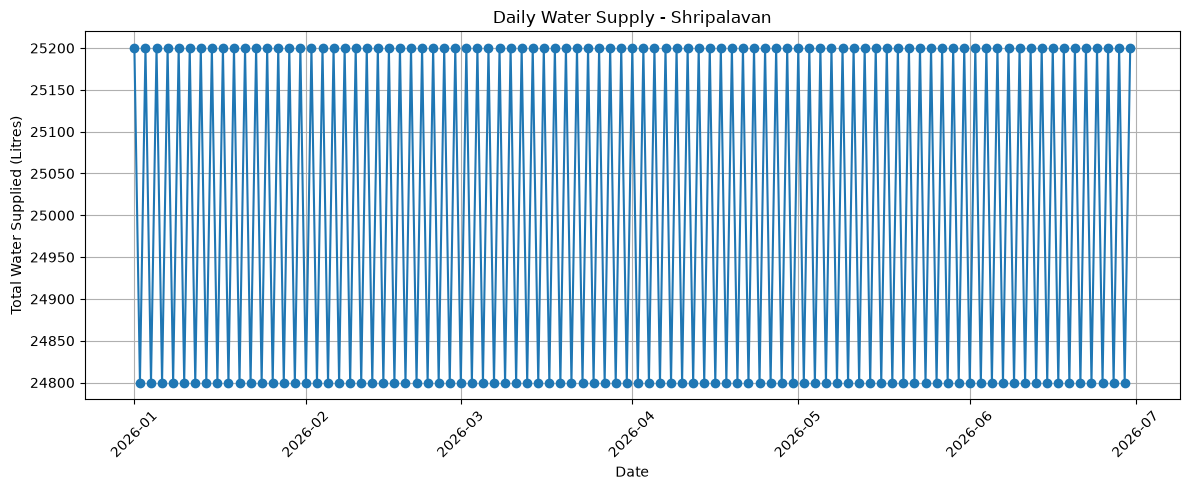

In [12]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["Date"],
    df["Total_Water_Supplied_L"],
    marker="o"
)

plt.title("Daily Water Supply - Shripalavan")
plt.xlabel("Date")
plt.ylabel("Total Water Supplied (Litres)")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

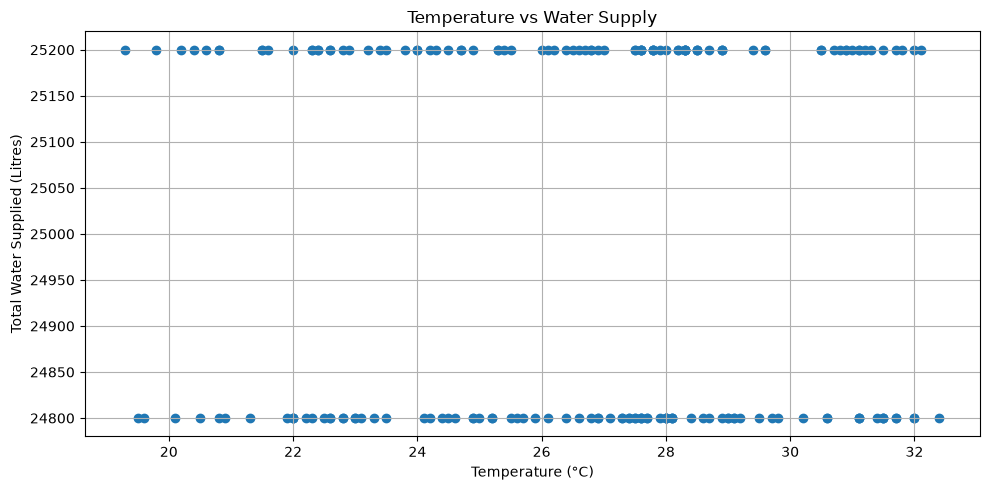

In [13]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df["Temperature"],
    df["Total_Water_Supplied_L"]
)

plt.title("Temperature vs Water Supply")
plt.xlabel("Temperature (°C)")
plt.ylabel("Total Water Supplied (Litres)")
plt.grid(True)

plt.tight_layout()
plt.show()


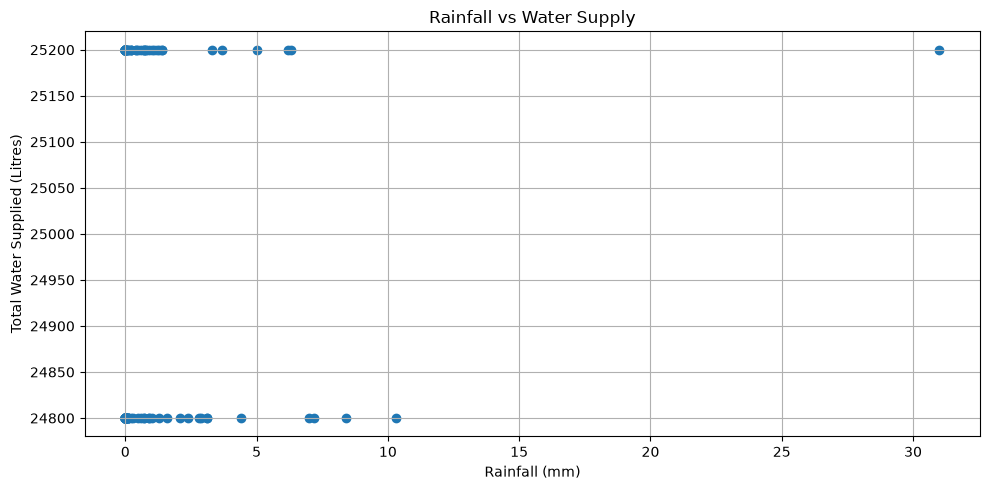

In [14]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df["Rainfall"],
    df["Total_Water_Supplied_L"]
)

plt.title("Rainfall vs Water Supply")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Total Water Supplied (Litres)")
plt.grid(True)

plt.tight_layout()
plt.show()


In [15]:
features = [
    "Households_Supplied",
    "Water_Per_Household_L",
    "Day",
    "Month",
    "Day_of_Week",
    "Temperature",
    "Rainfall",
    "Humidity"
]

X = df[features]
y = df["Total_Water_Supplied_L"]

print("Features Shape:", X.shape)

print("Target Shape:", y.shape)


Features Shape: (181, 8)
Target Shape: (181,)


In [16]:
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)


Training Data: (144, 8)
Testing Data: (37, 8)


In [17]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Random Forest Model trained successfully!")


Random Forest Model trained successfully!


In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-----------------")
print("MAE  :", mae)
print("RMSE :", rmse)
print("R²   :", r2)


Model Evaluation
-----------------
MAE  : 0.0
RMSE : 0.0
R²   : 1.0


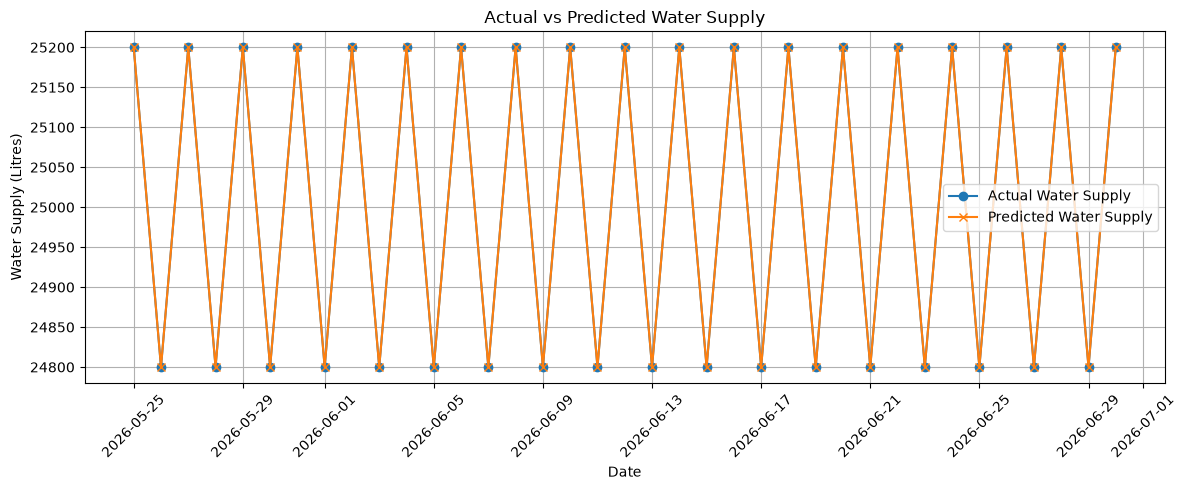

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["Date"].iloc[split_index:],
    y_test.values,
    label="Actual Water Supply",
    marker="o"
)

plt.plot(
    df["Date"].iloc[split_index:],
    y_pred,
    label="Predicted Water Supply",
    marker="x"
)

plt.title("Actual vs Predicted Water Supply")
plt.xlabel("Date")
plt.ylabel("Water Supply (Litres)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [20]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(model, "../models/water_demand_model.pkl")

print("Model saved successfully!")


Model saved successfully!


In [21]:
future_dates = pd.date_range(
    start=df["Date"].max() + pd.Timedelta(days=1),
    periods=7,
    freq="D"
)

future_df = pd.DataFrame({
    "Date": future_dates,
    "Households_Supplied": [
        63 if i % 2 == 0 else 62
        for i in range(7)
    ],
    "Water_Per_Household_L": [400] * 7
})

future_df["Day"] = future_df["Date"].dt.day
future_df["Month"] = future_df["Date"].dt.month
future_df["Day_of_Week"] = future_df["Date"].dt.dayofweek

# सध्या future weather साठी शेवटच्या available weather values वापरत आहोत
future_df["Temperature"] = df["Temperature"].iloc[-1]
future_df["Rainfall"] = df["Rainfall"].iloc[-1]
future_df["Humidity"] = df["Humidity"].iloc[-1]

future_X = future_df[features]

future_df["Predicted_Water_Demand_L"] = model.predict(future_X)

future_df


,Date,Households_Supplied,Water_Per_Household_L,Day,Month,Day_of_Week,Temperature,Rainfall,Humidity,Predicted_Water_Demand_L
0,2026-07-01,63,400,1,7,2,24.5,3.7,82,25200.0
1,2026-07-02,62,400,2,7,3,24.5,3.7,82,24800.0
2,2026-07-03,63,400,3,7,4,24.5,3.7,82,25200.0
3,2026-07-04,62,400,4,7,5,24.5,3.7,82,24800.0
4,2026-07-05,63,400,5,7,6,24.5,3.7,82,25200.0
5,2026-07-06,62,400,6,7,0,24.5,3.7,82,24800.0
6,2026-07-07,63,400,7,7,1,24.5,3.7,82,25200.0


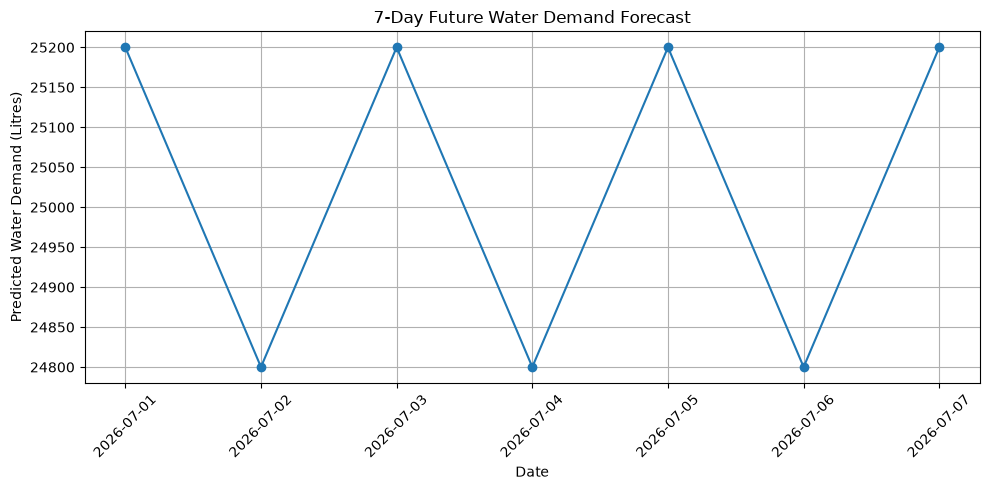

In [22]:
plt.figure(figsize=(10, 5))

plt.plot(
    future_df["Date"],
    future_df["Predicted_Water_Demand_L"],
    marker="o"
)

plt.title("7-Day Future Water Demand Forecast")
plt.xlabel("Date")
plt.ylabel("Predicted Water Demand (Litres)")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()


In [23]:
results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [mae, rmse, r2]
})

results


,Metric,Value
0,MAE,0.0
1,RMSE,0.0
2,R²,1.0


In [24]:
results = pd.DataFrame({
    "Metri
    c": ["MAE", "RMSE", "R²"],
    "Value": [mae, rmse, r2]
})

results


SyntaxError: unterminated string literal (detected at line 2) (1557796391.py, line 2)

In [25]:
results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [mae, rmse, r2]
})

results

,Metric,Value
0,MAE,0.0
1,RMSE,0.0
2,R²,1.0


In [27]:
from sklearn.linear_model omport Linear Regression
lr_model = LinearRegression()
lr_ model =.fit(X_train, y_train)
print("Linear Regression Model trained successsfully!")

SyntaxError: invalid syntax (4284724230.py, line 1)

In [32]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("Linear Regression Model trained successsfully!")

Linear Regression Model trained successsfully!


In [37]:
lr_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Evaluation")
print("----------------------------")
print("MAE  :", lr_mae)
print("RMSE :", lr_rmse)
print("R²   :", lr_r2)

Linear Regression Evaluation
----------------------------
MAE  : 0.0
RMSE : 0.0
R²   : 1.0


In [38]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "Linear Regression"],
    "MAE": [mae, lr_mae],
    "RMSE": [rmse, lr_rmse],
    "R2": [r2, lr_r2]
})

comparison


,Model,MAE,RMSE,R2
0,Random Forest,0.0,0.0,1.0
1,Linear Regression,0.0,0.0,1.0


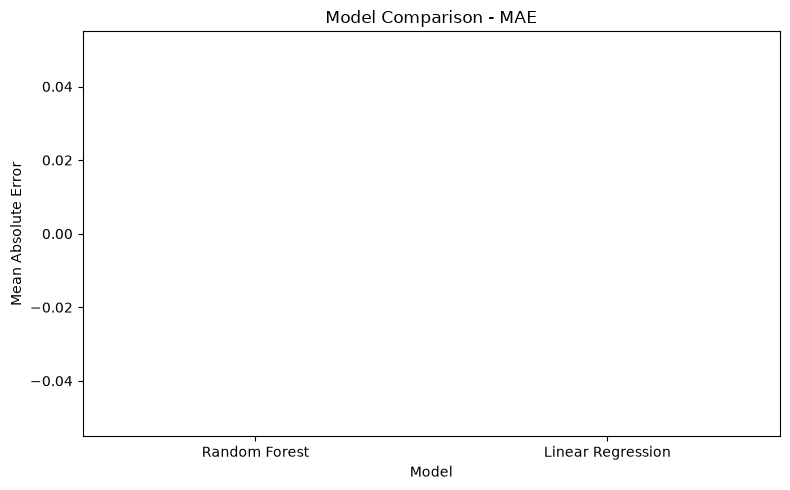

In [39]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["MAE"]
)

plt.title("Model Comparison - MAE")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")

plt.tight_layout()
plt.show()


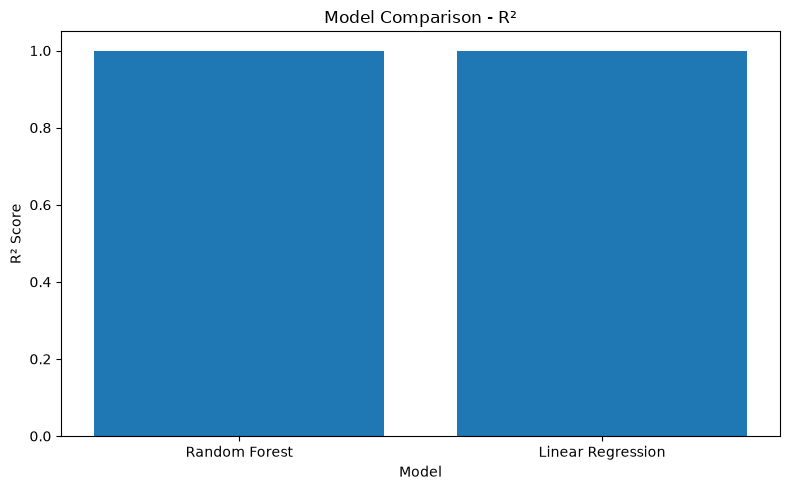

In [40]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["R2"]
)

plt.title("Model Comparison - R²")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.tight_layout()
plt.show()


In [41]:
prediction_results = pd.DataFrame({
    "Date": df["Date"].iloc[split_index:],
    "Actual_Water_Supply_L": y_test.values,
    "Predicted_Water_Supply_L": y_pred
})

prediction_results.head(10)

,Date,Actual_Water_Supply_L,Predicted_Water_Supply_L
144,2026-05-25,25200,25200.0
145,2026-05-26,24800,24800.0
146,2026-05-27,25200,25200.0
147,2026-05-28,24800,24800.0
148,2026-05-29,25200,25200.0
149,2026-05-30,24800,24800.0
150,2026-05-31,25200,25200.0
151,2026-06-01,24800,24800.0
152,2026-06-02,25200,25200.0
153,2026-06-03,24800,24800.0


In [42]:
prediction_results["Error_L"] = (
    prediction_results["Actual_Water_Supply_L"]
    - prediction_results["Predicted_Water_Supply_L"]
)

prediction_results.head(10)

,Date,Actual_Water_Supply_L,Predicted_Water_Supply_L,Error_L
144,2026-05-25,25200,25200.0,0.0
145,2026-05-26,24800,24800.0,0.0
146,2026-05-27,25200,25200.0,0.0
147,2026-05-28,24800,24800.0,0.0
148,2026-05-29,25200,25200.0,0.0
149,2026-05-30,24800,24800.0,0.0
150,2026-05-31,25200,25200.0,0.0
151,2026-06-01,24800,24800.0,0.0
152,2026-06-02,25200,25200.0,0.0
153,2026-06-03,24800,24800.0,0.0


In [43]:
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(model, "models/water_demand_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [44]:
import os

print(os.path.exists("models/water_demand_model.pkl"))
print(os.path.getsize("models/water_demand_model.pkl"), "bytes")


True
54465 bytes


In [45]:
import os

os.makedirs("app", exist_ok=True)

print("app folder created successfully!")


app folder created successfully!


In [46]:
open("app/app.py", "w").close()

print("app.py created successfully!")

app.py created successfully!


In [47]:
open("app/app.py", "w").close()

print("app.py created successfully!")

app.py created successfully!


In [48]:
import streamlit

print("Streamlit version:", streamlit.__version__)

Streamlit version: 1.64.0


In [49]:
%%writefile app/app.py

import streamlit as st
import pandas as pd
import joblib

st.set_page_config(
    page_title="Water Demand Forecasting",
    page_icon="💧",
    layout="wide"
)

st.title("💧 Water Demand Forecasting")
st.subheader("Shripalavan, Taluka Man, District Satara")

st.write(
    "AI & ML based Water Demand Forecasting Dashboard"
)


Overwriting app/app.py


In [5]:
cd C:\Users\HP\Water-Demand-Forecasting

C:\Users\HP\Water-Demand-Forecasting


In [6]:
%%writefile app/app.py

import streamlit as st
import pandas as pd
import joblib

st.set_page_config(
    page_title="Water Demand Forecasting",
    page_icon="💧",
    layout="wide"
)

st.title("💧 Water Demand Forecasting")
st.subheader("Shripalavan, Taluka Man, District Satara")

st.write("AI & ML based Water Demand Forecasting Dashboard")

# Load dataset
df = pd.read_csv("dataset/water_demand.csv")
df["Date"] = pd.to_datetime(df["Date"])

# Load trained model
model = joblib.load("models/water_demand_model.pkl")

st.success("Random Forest Model Loaded Successfully!")

st.write("### Dataset Preview")
st.dataframe(df.head(10))

Overwriting app/app.py


In [8]:
%%writefile app/app.py

import streamlit as st
import pandas as pd
import joblib

st.set_page_config(
    page_title="Water Demand Forecasting",
    page_icon="💧",
    layout="wide"
)

st.title("💧 Water Demand Forecasting")
st.subheader("Shripalavan, Taluka Man, District Satara")

st.write("AI & ML based Water Demand Forecasting Dashboard")

# Load dataset
df = pd.read_csv("dataset/water_demand.csv")
df["Date"] = pd.to_datetime(df["Date"])

# Load trained model
model = joblib.load("models/water_demand_model.pkl")

st.success("Random Forest Model Loaded Successfully!")

st.write("### Dataset Preview")
st.dataframe(df.head(10))

st.write("### Key Water Statistics")

col1, col2, col3 = st.columns(3)

with col1:
    st.metric("Population", "520")

with col2:
    st.metric("Households", "125")

with col3:
    st.metric("Avg. Daily Supply", "25,000 L")

Overwriting app/app.py


In [10]:
%%writefile app/app.py

import streamlit as st
import pandas as pd
import joblib

# -------------------------------------------------
# Page Configuration
# -------------------------------------------------

st.set_page_config(
    page_title="Water Demand Forecasting",
    page_icon="💧",
    layout="wide"
)

# -------------------------------------------------
# Title
# -------------------------------------------------

st.title("💧 Water Demand Forecasting")
st.subheader("Shripalavan, Taluka Man, District Satara")

st.write(
    "AI & ML based Water Demand Forecasting Dashboard"
)

# -------------------------------------------------
# Load Dataset
# -------------------------------------------------

df = pd.read_csv("dataset/water_demand.csv")
df["Date"] = pd.to_datetime(df["Date"])

# -------------------------------------------------
# Load Trained Model
# -------------------------------------------------

model = joblib.load("models/water_demand_model.pkl")

st.success("Random Forest Model Loaded Successfully!")

# -------------------------------------------------
# Key Water Statistics
# -------------------------------------------------

st.write("### Key Water Statistics")

col1, col2, col3 = st.columns(3)

with col1:
    st.metric("Population", "520")

with col2:
    st.metric("Households", "125")

with col3:
    st.metric("Avg. Daily Supply", "25,000 L")

# -------------------------------------------------
# Dataset Preview
# -------------------------------------------------

st.write("### Dataset Preview")

st.dataframe(df.head(10))

# -------------------------------------------------
# Daily Water Supply Chart
# -------------------------------------------------

st.write("### Daily Water Supply")

chart_data = df[["Date", "Total_Water_Supplied_L"]].copy()
chart_data = chart_data.set_index("Date")

st.line_chart(chart_data)

Overwriting app/app.py


In [11]:
%%writefile app/app.py

import streamlit as st
import pandas as pd
import joblib

# -------------------------------------------------
# Page Configuration
# -------------------------------------------------

st.set_page_config(
    page_title="Water Demand Forecasting",
    page_icon="💧",
    layout="wide"
)

# -------------------------------------------------
# Title
# -------------------------------------------------

st.title("💧 Water Demand Forecasting")
st.subheader("Shripalavan, Taluka Man, District Satara")

st.write(
    "AI & ML based Water Demand Forecasting Dashboard"
)

# -------------------------------------------------
# Load Dataset
# -------------------------------------------------

df = pd.read_csv("dataset/water_demand.csv")
df["Date"] = pd.to_datetime(df["Date"])

# -------------------------------------------------
# Load Trained Model
# -------------------------------------------------

model = joblib.load("models/water_demand_model.pkl")

st.success("Random Forest Model Loaded Successfully!")

# -------------------------------------------------
# Key Water Statistics
# -------------------------------------------------

st.write("### Key Water Statistics")

col1, col2, col3 = st.columns(3)

with col1:
    st.metric("Population", "520")

with col2:
    st.metric("Households", "125")

with col3:
    st.metric("Avg. Daily Supply", "25,000 L")

# -------------------------------------------------
# Dataset Preview
# -------------------------------------------------

st.write("### Dataset Preview")

st.dataframe(df.head(10))

# -------------------------------------------------
# Daily Water Supply Chart
# -------------------------------------------------

st.write("### Daily Water Supply")

chart_data = df[
    ["Date", "Total_Water_Supplied_L"]
].copy()

chart_data = chart_data.set_index("Date")

st.line_chart(chart_data)

# -------------------------------------------------
# 7-Day Future Forecast
# -------------------------------------------------

st.write("### 🔮 7-Day Water Demand Forecast")

future_dates = pd.date_range(
    start=df["Date"].max() + pd.Timedelta(days=1),
    periods=7,
    freq="D"
)

future_df = pd.DataFrame({
    "Date": future_dates,
    "Households_Supplied": [
        63 if i % 2 == 0 else 62
        for i in range(7)
    ],
    "Water_Per_Household_L": [400] * 7
})

future_df["Day"] = future_df["Date"].dt.day
future_df["Month"] = future_df["Date"].dt.month
future_df["Day_of_Week"] = future_df["Date"].dt.dayofweek

# Placeholder weather values
future_df["Temperature"] = df["Temperature"].iloc[-1]
future_df["Rainfall"] = df["Rainfall"].iloc[-1]
future_df["Humidity"] = df["Humidity"].iloc[-1]

# Model features
features = [
    "Households_Supplied",
    "Water_Per_Household_L",
    "Day",
    "Month",
    "Day_of_Week",
    "Temperature",
    "Rainfall",
    "Humidity"
]

future_X = future_df[features]

# Prediction
future_df["Predicted_Water_Demand_L"] = model.predict(
    future_X
)

# Forecast Table
st.dataframe(
    future_df[
        ["Date", "Households_Supplied",
         "Predicted_Water_Demand_L"]
    ]
)

# Forecast Chart
forecast_chart = future_df[
    ["Date", "Predicted_Water_Demand_L"]
].copy()

forecast_chart = forecast_chart.set_index("Date")

st.write("### 7-Day Forecast Chart")

st.line_chart(forecast_chart)

Overwriting app/app.py


In [12]:
%%writefile app/app.py

import streamlit as st
import pandas as pd
import joblib

# -------------------------------------------------
# Page Configuration
# -------------------------------------------------

st.set_page_config(
    page_title="Water Demand Forecasting",
    page_icon="💧",
    layout="wide"
)

# -------------------------------------------------
# Title
# -------------------------------------------------

st.title("💧 Water Demand Forecasting")
st.subheader("Shripalavan, Taluka Man, District Satara")

st.write("AI & ML based Water Demand Forecasting Dashboard")

# -------------------------------------------------
# Load Dataset and Model
# -------------------------------------------------

df = pd.read_csv("dataset/water_demand.csv")
df["Date"] = pd.to_datetime(df["Date"])

model = joblib.load("models/water_demand_model.pkl")

st.success("Random Forest Model Loaded Successfully!")

# -------------------------------------------------
# Key Statistics
# -------------------------------------------------

st.write("### Key Water Statistics")

col1, col2, col3 = st.columns(3)

with col1:
    st.metric("Population", "520")

with col2:
    st.metric("Households", "125")

with col3:
    st.metric("Avg. Daily Supply", "25,000 L")

# -------------------------------------------------
# Dataset Preview
# -------------------------------------------------

st.write("### Dataset Preview")

st.dataframe(df.head(10))

# -------------------------------------------------
# Daily Water Supply Chart
# -------------------------------------------------

st.write("### Daily Water Supply")

chart_data = df[
    ["Date", "Total_Water_Supplied_L"]
].copy()

chart_data = chart_data.set_index("Date")

st.line_chart(chart_data)

# -------------------------------------------------
# Interactive Prediction
# -------------------------------------------------

st.write("### 🔮 Predict Water Demand")

col1, col2 = st.columns(2)

with col1:
    households = st.number_input(
        "Households Supplied",
        min_value=1,
        max_value=1000,
        value=63,
        step=1
    )

with col2:
    water_per_household = st.number_input(
        "Water Per Household (Litres)",
        min_value=1,
        max_value=2000,
        value=400,
        step=50
    )

predict_button = st.button("💧 Predict Water Demand")

if predict_button:

    latest_date = df["Date"].max() + pd.Timedelta(days=1)

    input_data = pd.DataFrame({
        "Households_Supplied": [households],
        "Water_Per_Household_L": [water_per_household],
        "Day": [latest_date.day],
        "Month": [latest_date.month],
        "Day_of_Week": [latest_date.dayofweek],
        "Temperature": [df["Temperature"].iloc[-1]],
        "Rainfall": [df["Rainfall"].iloc[-1]],
        "Humidity": [df["Humidity"].iloc[-1]]
    })

    features = [
        "Households_Supplied",
        "Water_Per_Household_L",
        "Day",
        "Month",
        "Day_of_Week",
        "Temperature",
        "Rainfall",
        "Humidity"
    ]

    prediction = model.predict(
        input_data[features]
    )[0]

    st.success(
        f"Predicted Water Demand: {prediction:,.0f} Litres"
    )

# -------------------------------------------------
# 7-Day Future Forecast
# -------------------------------------------------

st.write("### 📅 7-Day Water Demand Forecast")

future_dates = pd.date_range(
    start=df["Date"].max() + pd.Timedelta(days=1),
    periods=7,
    freq="D"
)

future_df = pd.DataFrame({
    "Date": future_dates,
    "Households_Supplied": [
        63 if i % 2 == 0 else 62
        for i in range(7)
    ],
    "Water_Per_Household_L": [400] * 7
})

future_df["Day"] = future_df["Date"].dt.day
future_df["Month"] = future_df["Date"].dt.month
future_df["Day_of_Week"] = future_df["Date"].dt.dayofweek

future_df["Temperature"] = df["Temperature"].iloc[-1]
future_df["Rainfall"] = df["Rainfall"].iloc[-1]
future_df["Humidity"] = df["Humidity"].iloc[-1]

features = [
    "Households_Supplied",
    "Water_Per_Household_L",
    "Day",
    "Month",
    "Day_of_Week",
    "Temperature",
    "Rainfall",
    "Humidity"
]

future_df["Predicted_Water_Demand_L"] = model.predict(
    future_df[features]
)

st.dataframe(
    future_df[
        [
            "Date",
            "Households_Supplied",
            "Predicted_Water_Demand_L"
        ]
    ]
)

# -------------------------------------------------
# Forecast Chart
# -------------------------------------------------

forecast_chart = future_df[
    ["Date", "Predicted_Water_Demand_L"]
].copy()

forecast_chart = forecast_chart.set_index("Date")

st.write("### 7-Day Forecast Chart")

st.line_chart(forecast_chart)

Overwriting app/app.py


In [13]:
%%writefile app/app.py

import streamlit as st
import pandas as pd
import joblib

# -------------------------------------------------
# Page Configuration
# -------------------------------------------------

st.set_page_config(
    page_title="Water Demand Forecasting",
    page_icon="💧",
    layout="wide"
)

# -------------------------------------------------
# Title
# -------------------------------------------------

st.title("💧 Water Demand Forecasting")
st.subheader("Shripalavan, Taluka Man, District Satara")

st.write(
    "AI & ML based Water Demand Forecasting Dashboard"
)

# -------------------------------------------------
# Load Dataset
# -------------------------------------------------

df = pd.read_csv("dataset/water_demand.csv")
df["Date"] = pd.to_datetime(df["Date"])

# -------------------------------------------------
# Load Trained Model
# -------------------------------------------------

model = joblib.load("models/water_demand_model.pkl")

st.success("Random Forest Model Loaded Successfully!")

# -------------------------------------------------
# Key Statistics
# -------------------------------------------------

st.write("### 📊 Key Water Statistics")

col1, col2, col3 = st.columns(3)

with col1:
    st.metric("Population", "520")

with col2:
    st.metric("Households", "125")

with col3:
    st.metric("Average Daily Supply", "25,000 L")

# -------------------------------------------------
# Dataset Preview
# -------------------------------------------------

st.write("### 📋 Dataset Preview")

st.dataframe(df.head(10))

# -------------------------------------------------
# Daily Water Supply Chart
# -------------------------------------------------

st.write("### 📈 Daily Water Supply")

chart_data = df[
    ["Date", "Total_Water_Supplied_L"]
].copy()

chart_data = chart_data.set_index("Date")

st.line_chart(chart_data)

# -------------------------------------------------
# Interactive Water Demand Prediction
# -------------------------------------------------

st.write("### 🔮 Predict Water Demand")

col1, col2 = st.columns(2)

with col1:
    households = st.number_input(
        "Households Supplied",
        min_value=1,
        max_value=125,
        value=63,
        step=1
    )

with col2:
    water_per_household = st.number_input(
        "Water Per Household (Litres)",
        min_value=1,
        max_value=2000,
        value=400,
        step=50
    )

predict_button = st.button("💧 Predict Water Demand")

if predict_button:

    prediction_date = df["Date"].max() + pd.Timedelta(days=1)

    input_data = pd.DataFrame({
        "Households_Supplied": [households],
        "Water_Per_Household_L": [water_per_household],
        "Day": [prediction_date.day],
        "Month": [prediction_date.month],
        "Day_of_Week": [prediction_date.dayofweek],
        "Temperature": [df["Temperature"].iloc[-1]],
        "Rainfall": [df["Rainfall"].iloc[-1]],
        "Humidity": [df["Humidity"].iloc[-1]]
    })

    features = [
        "Households_Supplied",
        "Water_Per_Household_L",
        "Day",
        "Month",
        "Day_of_Week",
        "Temperature",
        "Rainfall",
        "Humidity"
    ]

    prediction = model.predict(
        input_data[features]
    )[0]

    st.success(
        f"Predicted Water Demand: {prediction:,.0f} Litres"
    )

# -------------------------------------------------
# 7-Day Future Forecast
# -------------------------------------------------

st.write("### 📅 7-Day Water Demand Forecast")

future_dates = pd.date_range(
    start=df["Date"].max() + pd.Timedelta(days=1),
    periods=7,
    freq="D"
)

future_df = pd.DataFrame({
    "Date": future_dates,
    "Households_Supplied": [
        63 if i % 2 == 0 else 62
        for i in range(7)
    ],
    "Water_Per_Household_L": [400] * 7
})

future_df["Day"] = future_df["Date"].dt.day
future_df["Month"] = future_df["Date"].dt.month
future_df["Day_of_Week"] = future_df["Date"].dt.dayofweek

# Placeholder weather values
future_df["Temperature"] = df["Temperature"].iloc[-1]
future_df["Rainfall"] = df["Rainfall"].iloc[-1]
future_df["Humidity"] = df["Humidity"].iloc[-1]

features = [
    "Households_Supplied",
    "Water_Per_Household_L",
    "Day",
    "Month",
    "Day_of_Week",
    "Temperature",
    "Rainfall",
    "Humidity"
]

future_df["Predicted_Water_Demand_L"] = model.predict(
    future_df[features]
)

# -------------------------------------------------
# Forecast Table
# -------------------------------------------------

st.write("### Forecast Table")

st.dataframe(
    future_df[
        [
            "Date",
            "Households_Supplied",
            "Water_Per_Household_L",
            "Predicted_Water_Demand_L"
        ]
    ]
)

# -------------------------------------------------
# Forecast Chart
# -------------------------------------------------

forecast_chart = future_df[
    ["Date", "Predicted_Water_Demand_L"]
].copy()

forecast_chart = forecast_chart.set_index("Date")

st.write("### 📊 7-Day Forecast Chart")

st.line_chart(forecast_chart)

# -------------------------------------------------
# Footer
# -------------------------------------------------

st.write("---")

st.caption(
    "Water Demand Forecasting Project | "
    "Shripalavan, Taluka Man, District Satara"
)

Overwriting app/app.py


In [15]:
%%writefile app/app.py
http://localhost:8501

Overwriting app/app.py


In [16]:
%%writefile app/app.py

import streamlit as st

st.title("💧 Water Demand Forecasting")

st.write("Shripalavan, Taluka Man, District Satara")

st.success("Streamlit App Working Successfully!")

Overwriting app/app.py


In [17]:
%%writefile app/app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import os

# --------------------------------------------------
# PAGE CONFIGURATION
# --------------------------------------------------

st.set_page_config(
    page_title="Water Demand Forecasting",
    page_icon="💧",
    layout="wide"
)

# --------------------------------------------------
# TITLE
# --------------------------------------------------

st.title("💧 Water Demand Forecasting")

st.subheader(
    "Shripalavan, Taluka Man, District Satara, Maharashtra"
)

st.write(
    "AI & Machine Learning based Water Demand Forecasting System"
)

st.success("Water Demand Forecasting Dashboard")

# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------

DATA_PATH = "dataset/water_demand.csv"
MODEL_PATH = "models/water_demand_model.pkl"

try:
    df = pd.read_csv(DATA_PATH)
    df["Date"] = pd.to_datetime(df["Date"])

    model = joblib.load(MODEL_PATH)

except Exception as e:
    st.error(f"Error loading data/model: {e}")
    st.stop()

# --------------------------------------------------
# PROJECT INFORMATION
# --------------------------------------------------

st.header("📍 Project Information")

col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric("Population", "520")

with col2:
    st.metric("Households", "125")

with col3:
    st.metric(
        "Average Daily Supply",
        "25,000 L"
    )

with col4:
    st.metric(
        "Water / Household",
        "400 L"
    )

st.info(
    "Current supply pattern: Alternate-day water supply. "
    "Approximately 63 households receive 25,200 L and "
    "62 households receive 24,800 L."
)

# --------------------------------------------------
# DATASET PREVIEW
# --------------------------------------------------

st.header("📊 Dataset Preview")

st.write(
    f"Dataset contains {len(df)} daily records "
    f"from {df['Date'].min().date()} to {df['Date'].max().date()}."
)

st.dataframe(
    df,
    use_container_width=True
)

# --------------------------------------------------
# DAILY WATER SUPPLY GRAPH
# --------------------------------------------------

st.header("📈 Daily Water Supply")

fig1, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(
    df["Date"],
    df["Total_Water_Supplied_L"],
    marker="o"
)

ax1.set_title("Daily Water Supply - Shripalavan")
ax1.set_xlabel("Date")
ax1.set_ylabel("Water Supplied (Litres)")
ax1.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()

st.pyplot(fig1)

# --------------------------------------------------
# WEATHER VS WATER SUPPLY
# --------------------------------------------------

st.header("🌦️ Weather Analysis")

col1, col2 = st.columns(2)

with col1:

    fig2, ax2 = plt.subplots(figsize=(7, 5))

    ax2.scatter(
        df["Temperature"],
        df["Total_Water_Supplied_L"]
    )

    ax2.set_title("Temperature vs Water Supply")
    ax2.set_xlabel("Temperature (°C)")
    ax2.set_ylabel("Water Supply (Litres)")
    ax2.grid(True)

    st.pyplot(fig2)

with col2:

    fig3, ax3 = plt.subplots(figsize=(7, 5))

    ax3.scatter(
        df["Rainfall"],
        df["Total_Water_Supplied_L"]
    )

    ax3.set_title("Rainfall vs Water Supply")
    ax3.set_xlabel("Rainfall (mm)")
    ax3.set_ylabel("Water Supply (Litres)")
    ax3.grid(True)

    st.pyplot(fig3)

# --------------------------------------------------
# 7 DAY FUTURE FORECAST
# --------------------------------------------------

st.header("🔮 7-Day Water Demand Forecast")

future_dates = pd.date_range(
    start=df["Date"].max() + pd.Timedelta(days=1),
    periods=7,
    freq="D"
)

future_df = pd.DataFrame({
    "Date": future_dates,
    "Households_Supplied": [
        63 if i % 2 == 0 else 62
        for i in range(7)
    ],
    "Water_Per_Household_L": [400] * 7
})

future_df["Day"] = future_df["Date"].dt.day
future_df["Month"] = future_df["Date"].dt.month
future_df["Day_of_Week"] = future_df["Date"].dt.dayofweek

# Using last available weather values
future_df["Temperature"] = df["Temperature"].iloc[-1]
future_df["Rainfall"] = df["Rainfall"].iloc[-1]
future_df["Humidity"] = df["Humidity"].iloc[-1]

features = [
    "Households_Supplied",
    "Water_Per_Household_L",
    "Day",
    "Month",
    "Day_of_Week",
    "Temperature",
    "Rainfall",
    "Humidity"
]

future_X = future_df[features]

future_df["Predicted_Water_Demand_L"] = model.predict(
    future_X
)

st.dataframe(
    future_df[
        [
            "Date",
            "Households_Supplied",
            "Water_Per_Household_L",
            "Predicted_Water_Demand_L"
        ]
    ],
    use_container_width=True
)

# --------------------------------------------------
# FUTURE FORECAST GRAPH
# --------------------------------------------------

fig4, ax4 = plt.subplots(figsize=(12, 5))

ax4.plot(
    future_df["Date"],
    future_df["Predicted_Water_Demand_L"],
    marker="o"
)

ax4.set_title("7-Day Predicted Water Demand")
ax4.set_xlabel("Date")
ax4.set_ylabel("Predicted Water Demand (Litres)")
ax4.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()

st.pyplot(fig4)

# --------------------------------------------------
# INTERACTIVE WATER DEMAND PREDICTION
# --------------------------------------------------

st.header("🧮 Interactive Water Demand Prediction")

st.write(
    "Enter the number of households and water supplied "
    "per household to estimate total water demand."
)

col1, col2 = st.columns(2)

with col1:

    households = st.number_input(
        "Number of Households",
        min_value=1,
        max_value=125,
        value=63,
        step=1
    )

with col2:

    water_per_household = st.number_input(
        "Water per Household (Litres)",
        min_value=1,
        max_value=2000,
        value=400,
        step=50
    )

predict_button = st.button(
    "🔮 Predict Water Demand"
)

if predict_button:

    prediction_input = pd.DataFrame({
        "Households_Supplied": [households],
        "Water_Per_Household_L": [water_per_household],
        "Day": [df["Date"].iloc[-1].day],
        "Month": [df["Date"].iloc[-1].month],
        "Day_of_Week": [df["Date"].iloc[-1].dayofweek],
        "Temperature": [df["Temperature"].iloc[-1]],
        "Rainfall": [df["Rainfall"].iloc[-1]],
        "Humidity": [df["Humidity"].iloc[-1]]
    })

    prediction = model.predict(
        prediction_input[features]
    )[0]

    st.success(
        f"💧 Predicted Water Demand: "
        f"{prediction:,.0f} Litres"
    )

    # Simple calculated value for reference
    calculated_demand = (
        households * water_per_household
    )

    st.info(
        f"Reference calculation: "
        f"{households} households × "
        f"{water_per_household} L = "
        f"{calculated_demand:,.0f} L"
    )

# --------------------------------------------------
# MODEL INFORMATION
# --------------------------------------------------

st.header("🤖 Machine Learning Model")

st.write(
    "The dashboard uses a Random Forest Regression model "
    "trained on household, water supply, calendar and weather features."
)

st.write("### Model Features")

st.write(
    """
    - Households Supplied
    - Water per Household
    - Day
    - Month
    - Day of Week
    - Temperature
    - Rainfall
    - Humidity
    """
)

# --------------------------------------------------
# IMPORTANT PROJECT NOTE
# --------------------------------------------------

st.warning(
    "Project Note: The current water-supply target values are "
    "based on the simulated 400 L per household baseline. "
    "For real-world forecasting, measured historical water "
    "consumption/supply data should be used."
)

# --------------------------------------------------
# FOOTER
# --------------------------------------------------

st.write("---")

st.caption(
    "Water Demand Forecasting Project | "
    "Shripalavan, Taluka Man, District Satara"
)

Overwriting app/app.py
